In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

In [22]:
df = pd.read_csv('SuperMarket Analysis.csv')

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [24]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No null values found!")

No null values found!


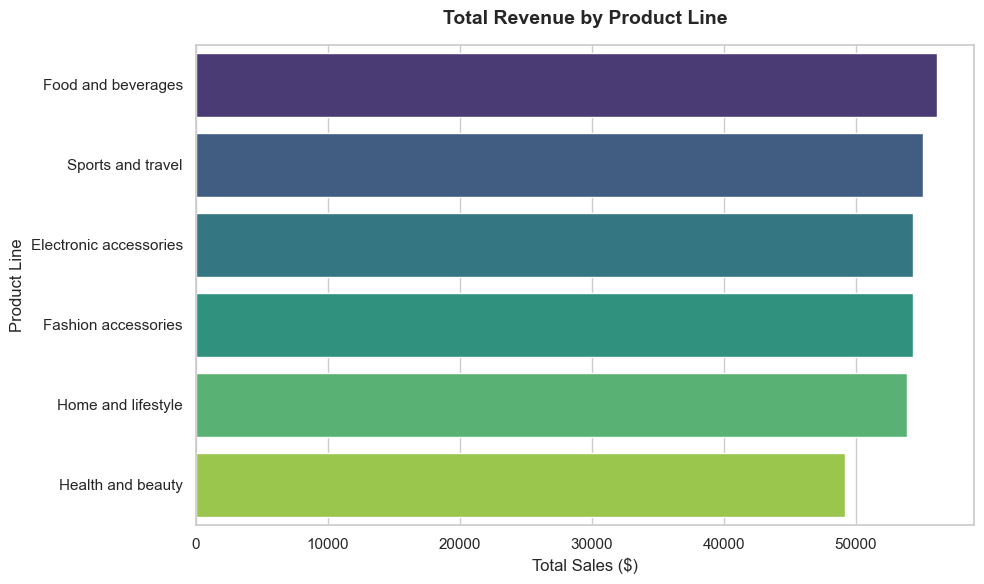

In [25]:
#Total Sales by Product Line
plt.figure(figsize=(10, 6))
product_sales = df.groupby('Product line')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
sns.barplot(x='Sales', y='Product line', data=product_sales, palette='viridis')
plt.title('Total Revenue by Product Line', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Line', fontsize=12)
plt.tight_layout()
plt.show()

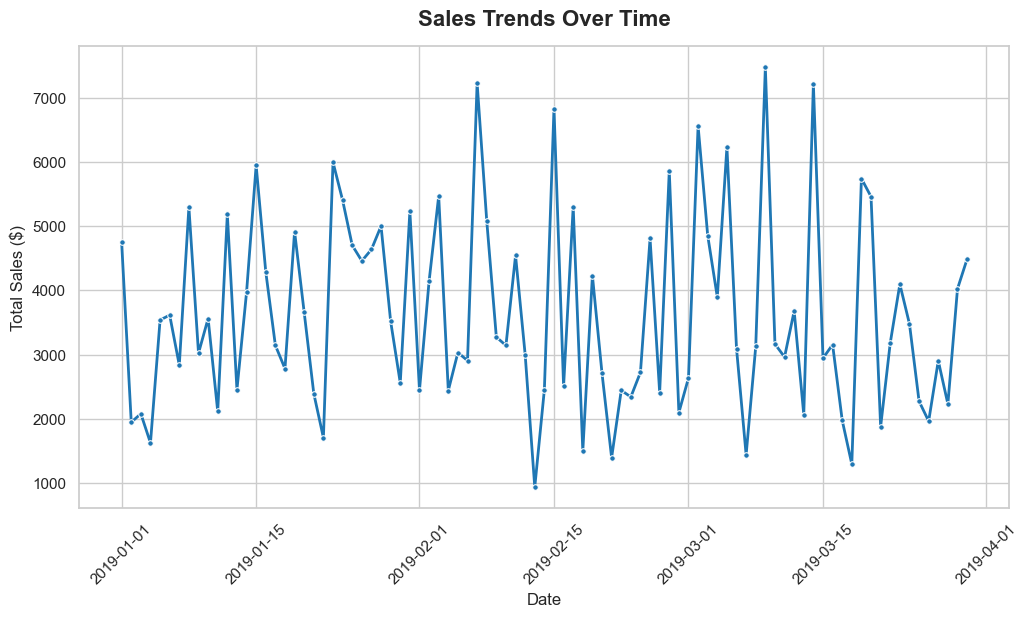

In [26]:
#Sales Trends Over Time
plt.figure(figsize=(12, 6))
df_time = df.copy()
df_time['Date'] = pd.to_datetime(df_time['Date'])
daily_sales = df_time.groupby('Date')['Sales'].sum().reset_index()
sns.lineplot(x='Date', y='Sales', data=daily_sales, color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.title('Sales Trends Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [27]:
#Setup Preprocessing Pipeline
X = df.drop(columns=['Sales', 'Invoice ID', 'Date', 'Time'])
y = df['Sales']
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

print("Preprocessing Done")

Preprocessing Done


In [28]:
#Defining Models
models = {
    'SVM': SVR(kernel='rbf', C=1000, epsilon=0.1, gamma='scale'),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

#Stacking Ensemble
base_estimators = [(name, model) for name, model in models.items()]
models['Stacking Ensemble'] = StackingRegressor(
    estimators=base_estimators, 
    final_estimator=LinearRegression(), 
    cv=5, 
    n_jobs=-1
)

print("Models initialized")

Models initialized


In [29]:
#Training and Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
predictions = {}

print("Training models")
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred
  
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results.append({'Model': name, 'R² Score': r2, 'MAE': mae, 'MSE': mse})

results_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False).reset_index(drop=True)
display(results_df)

Training models


,Model,R² Score,MAE,MSE
0,Stacking Ensemble,0.999981,0.718877,1.250284
1,Random Forest,0.999974,0.742538,1.689090
2,XGBoost,0.999794,2.296644,13.390387
3,SVM,0.999732,2.999740,17.414038


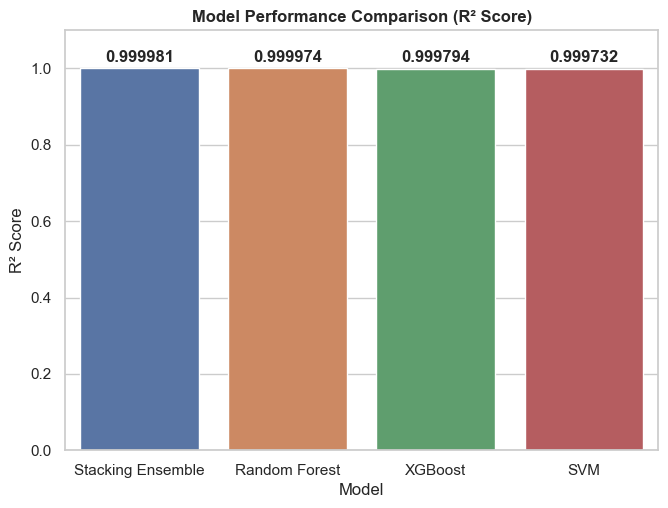

In [30]:
#Model Accuracy Comparison
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 4)

#R-Squared Comparison
ax_bar = fig.add_subplot(gs[0, 1:3])
sns.barplot(ax=ax_bar, x='Model', y='R² Score', data=results_df, palette=['#4c72b0', '#dd8452', '#55a868', '#c44e52'])
ax_bar.set_title('Model Performance Comparison (R² Score)', fontweight='bold')
ax_bar.set_ylim(0, 1.1)
for p in ax_bar.patches:
    ax_bar.annotate(f"{p.get_height():.6f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')
plt.show()

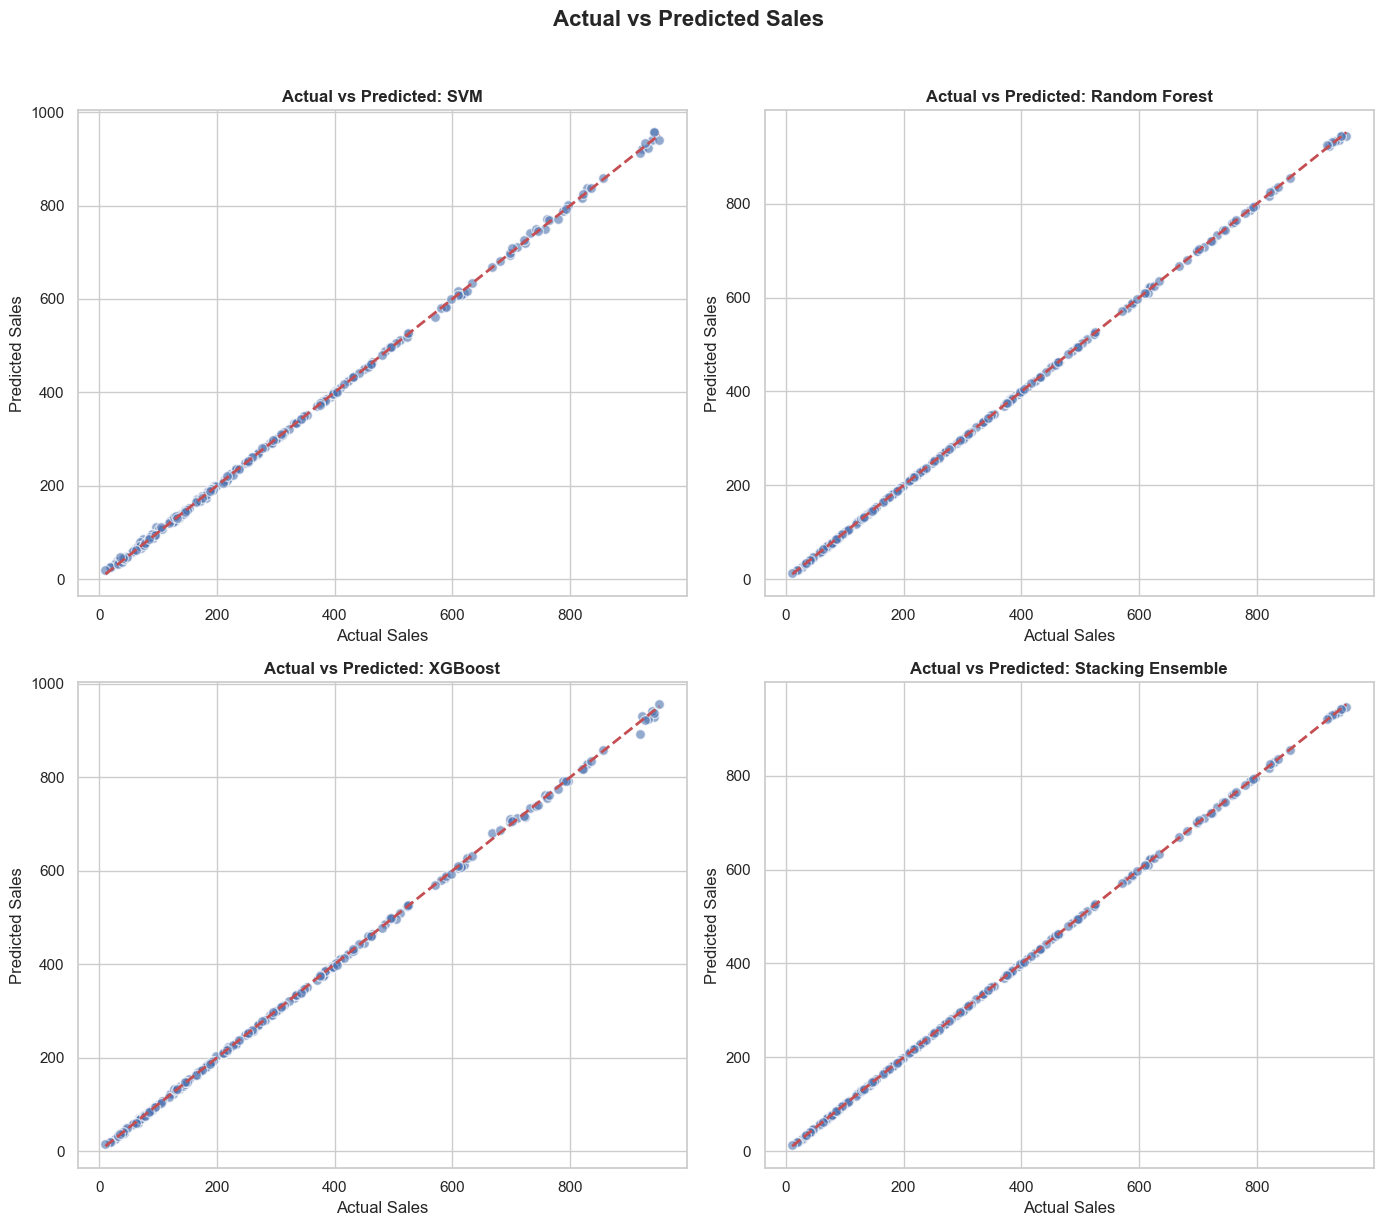

In [31]:
#Actual vs Predicted Sales
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.6, color='#4c72b0', edgecolors='w', s=50)
    
    min_val, max_val = y_test.min(), y_test.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    ax.set_title(f'Actual vs Predicted: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')

plt.suptitle('Actual vs Predicted Sales ', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
#XAI-Permutation Importance
best_model_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', models['Stacking Ensemble'])
])
best_model_pipe.fit(X_train, y_train)

result = permutation_importance(
    best_model_pipe, X_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1,
    scoring='r2'
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=True)

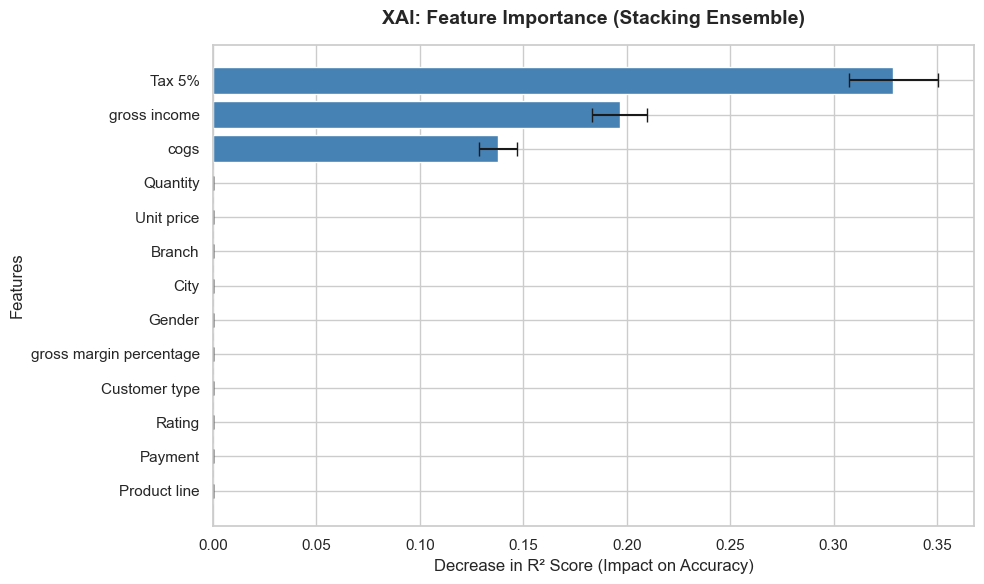


Top 3 Sales Drivers
     Feature  Importance_Mean  Importance_Std
      Tax 5%         0.328870        0.021438
gross income         0.196558        0.013393
        cogs         0.137818        0.008995


In [33]:
#Visual Importance
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.barh(
    importance_df['Feature'], 
    importance_df['Importance_Mean'], 
    xerr=importance_df['Importance_Std'], 
    color='steelblue', 
    capsize=5
)

plt.title('XAI: Feature Importance (Stacking Ensemble)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decrease in R² Score (Impact on Accuracy)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

print("\nTop 3 Sales Drivers")
print(importance_df.tail(3)[::-1].to_string(index=False))

In [34]:
#Business Impact Analysis Table
importance_summary = importance_df.sort_values(by='Importance_Mean', ascending=False).copy()
importance_summary.columns = ['Feature', 'Avg Accuracy Drop', 'Measurement Uncertainty (Std)']

print("Business Impact Analysis")
display(importance_summary.reset_index(drop=True))

Business Impact Analysis


,Feature,Avg Accuracy Drop,Measurement Uncertainty (Std)
0,Tax 5%,3.288696e-01,2.143831e-02
1,gross income,1.965579e-01,1.339269e-02
2,cogs,1.378178e-01,8.994608e-03
3,Quantity,1.050711e-05,1.313749e-06
4,Unit price,6.639201e-06,1.931968e-06
5,Branch,3.933776e-07,4.395361e-07
6,City,1.858086e-07,1.817312e-07
7,Gender,1.057438e-07,1.338031e-07
8,gross margin percentage,0.000000e+00,0.000000e+00
9,Customer type,-8.114462e-08,4.208163e-07


In [35]:
#Summary
best_model_name = results_df.iloc[0]['Model']
best_accuracy_pct = results_df.iloc[0]['R² Score'] * 100
top_driver = importance_df.iloc[-1]['Feature']


print("       SUPERMARKET SALES ANALYSIS")

print(f"Total Transactions Analyzed : {len(df)}")
print(f"Top Revenue Generator      : {df.groupby('Product line')['Sales'].sum().idxmax()}")
print(f"Best AI Forecasting Model  : {best_model_name}")
print(f"Model Prediction Accuracy  : {best_accuracy_pct:.6f}%")
print(f"Most Important Sales Factor: {top_driver}")


       SUPERMARKET SALES ANALYSIS
Total Transactions Analyzed : 1000
Top Revenue Generator      : Food and beverages
Best AI Forecasting Model  : Stacking Ensemble
Model Prediction Accuracy  : 99.998078%
Most Important Sales Factor: Tax 5%
